# FYS-STK4155 - Project 1

### Exercise 1a and 1b:

In [1]:
# --- Imports --- #

import numpy as np
import matplotlib.pyplot as plt
import sklearn

seed = 2026
np.random.seed(seed)

In [2]:
# --- Define functions --- #

def runge(x):
    """Runge's function"""

    return 1/(1 + 25*x**2)

def closed_form(X, y, lam):

    n, p = X.shape
    return np.linalg.pinv(X.T @ X + n*lam*np.eye(p)) @ X.T @ y

def scale(X):

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_std[X_std == 0] = 1 
    X_norm = (X - X_mean) / X_std

    return X_norm

def centre(y):

    y_mean = y.mean()
    y_centered = y - y_mean

    return y_centered

def MSE(y, y_hat):
    """Function for calculating Mean Sqared ERROR between y and y_hat"""

    mse = 0
    n = len(y)

    for i in range(n):
        mse += (y[i,0] - y_hat[i,0])**2
    mse = mse/n

    y_mean = 0
    for i in range(n):
        y_mean += y[i,0]
    y_mean = y_mean/n

    return mse

def R_squared(y, y_hat):
    """Function for R2 ERROR between y and y_hat"""

    n = len(y)

    SSE = 0
    SST = 0

    y_mean = 0
    for i in range(n):
        y_mean += y[i,0]
    y_mean = y_mean/n

    for i in range(n):
        SSE += (y[i,0] - y_hat[i,0])**2
        SST += (y[i,0] - y_mean)**2

    R2_score = 1 - SSE/SST

    return R2_score

In [3]:
# --- Setup Data --- #

n = 100
sigma = 0.1
x0, x1 = -1, 1

x = np.linspace(x0, x1, n).reshape(-1, 1)
y = runge(x) + np.random.normal(0, sigma, x.shape)

training_portion = 3/5
x_training, x_test, y_training, y_test = sklearn.model_selection.train_test_split(x, y, test_size=(1 - training_portion), random_state=seed)

In [4]:
# --- Compute train and test MSE and R² for OLS at each polynomial degree --- #

p = 16
lam = 0.0

X_training = np.vander(x_training.reshape(-1), p, increasing=True)[:, 1:] 
X_test = np.vander(x_test.reshape(-1), p, increasing=True)[:, 1:] 

X_training = scale(X_training)
X_test = scale(X_test)
y_training = centre(y_training)
y_test = centre(y_test)

MSE_train = np.zeros(p - 1)
MSE_test = np.zeros(p - 1)
R2_train = np.zeros(p - 1)
R2_test = np.zeros(p - 1)

theta_OLS_list = np.zeros((p - 1, p - 1))

for i in range(1, p):
    Xtr = X_training[:, :i]
    Xte = X_test[:, :i]

    theta_OLS = closed_form(Xtr, y_training, lam)
    theta_OLS_list[i - 1, :i] = theta_OLS.reshape(-1)

    y_hat_train = Xtr @ theta_OLS
    y_hat_test = Xte @ theta_OLS

    MSE_train[i - 1] = MSE(y_training, y_hat_train)
    MSE_test[i - 1] = MSE(y_test, y_hat_test)
    R2_train[i - 1] = R_squared(y_training, y_hat_train)
    R2_test[i - 1] = R_squared(y_test, y_hat_test)



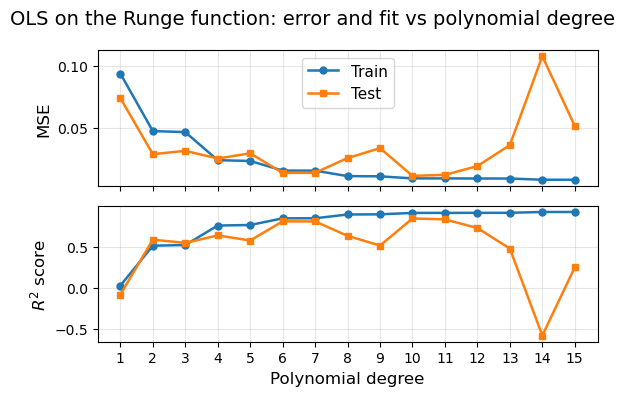

In [5]:
# --- Plot --- #

degrees = np.arange(1, p)

fig, (ax_mse, ax_R2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax_mse.plot(degrees, MSE_train, marker="o", markersize=5, linewidth=1.8, label="Train")
ax_mse.plot(degrees, MSE_test, marker="s", markersize=5, linewidth=1.8, label="Test")
ax_mse.set_ylabel("MSE", fontsize=12)
ax_mse.grid(True, alpha=0.3)
ax_mse.legend(fontsize=11)

ax_R2.plot(degrees, R2_train, marker="o", markersize=5, linewidth=1.8, label="Train")
ax_R2.plot(degrees, R2_test, marker="s", markersize=5, linewidth=1.8, label="Test")
ax_R2.set_ylabel(r"$R^2$ score", fontsize=12)
ax_R2.set_xlabel("Polynomial degree", fontsize=12)
ax_R2.set_xticks(degrees)
ax_R2.grid(True, alpha=0.3)  

fig.suptitle("OLS on the Runge function: error and fit vs polynomial degree", fontsize=14)
fig.tight_layout()

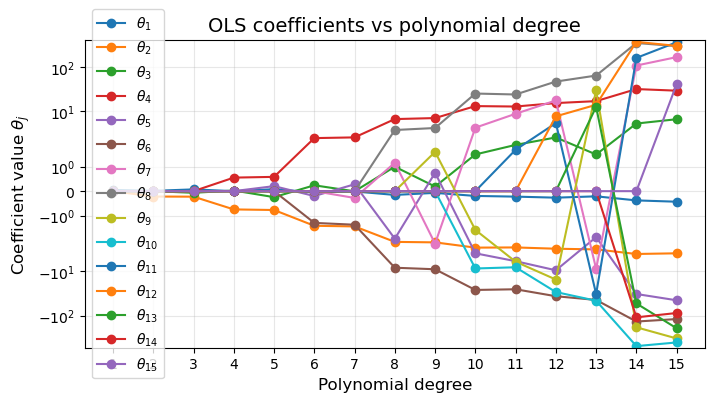

In [6]:
plt.figure(figsize=(8, 4))
for i in range(p - 1):
    plt.plot(degrees, theta_OLS_list[:, i], marker="o", label=rf"$\theta_{{{i + 1}}}$")

plt.legend(loc="center left")
plt.xlabel("Polynomial degree", fontsize=12)
plt.ylabel(r"Coefficient value $\theta_j$", fontsize=12)
plt.title("OLS coefficients vs polynomial degree", fontsize=14)
plt.xticks(degrees)
plt.yscale("symlog")
plt.grid(True, alpha=0.3)

In [7]:
def k_fold(x, k):
    """Function for splitting data into K parts"""

    folds = (len(x) // k)
    split_indices = np.zeros(k + 1, dtype=int)

    for i in range(k):  
        split_indices[i] = (i)*folds

    split_indices[-1] = len(x)

    return split_indices

def cross_validation(x, y, k, p, lam):
    """Function for performing cross.validation of data"""

    k_indices = k_fold(x, k)
    mse_scores = np.zeros(k)

    for i in range(k):
        x_test = x[k_indices[i]:k_indices[i + 1]]
        y_test = y[k_indices[i]:k_indices[i + 1]]

        x_train = np.concatenate([x[0:k_indices[i]], x[k_indices[i + 1]:]])
        y_train = np.concatenate([y[0:k_indices[i]], y[k_indices[i + 1]:]])

        X_test = x_test[:, 0:1] ** np.arange(p)
        X_train = x_train[:, 0:1] ** np.arange(p)

        mean = X_train[:, 1:].mean(axis=0)
        std = X_train[:, 1:].std(axis=0)

        X_train[:, 1:] = (X_train[:, 1:] - mean) / std
        X_test[:, 1:] = (X_test[:, 1:] - mean) / std

        ridge = np.eye(p) * lam
        theta_hat_OLS = np.linalg.inv(X_train.T @ X_train + ridge) @ X_train.T @ y_train
        y_hat = X_test @ theta_hat_OLS

        mse_scores[i] = np.mean((y_test - y_hat)**2)

    mean_mse = np.mean(mse_scores)
    std_mse = np.std(mse_scores)

    return mean_mse, std_mse

In [8]:
def gradient_descent(X, y, gamma, iterations, lam=0.0, tol=1e-8):
    n, n_features = X.shape
    theta = np.zeros(n_features)

    for t in range(iterations):
       
        grad = (2/n)*X.T @ (X @ theta - y) + 2*lam*theta

        theta = theta - gamma*grad

        if np.linalg.norm(grad) < tol:
            break

    return theta